In [ ]:
using Pkg
Pkg.add("Random")
Pkg.add("JuMP")
Pkg.add("Gurobi")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")

using JuMP, Gurobi, CSV, DataFrames

### First model: λ = 0 and α = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a}
#### Dynamics:
####   w[i,t+1,a+1] = w[i,t,a] - x[i,t,a]
####   w[i,t,1]     = N[i,t]  (new arrivals at a=0)

#### Capacity per time t is fixed input Cap[t]

In [18]:
waiting_df = CSV.read("ED_waiting_time.csv", DataFrame)
arrivals_df = CSV.read("ED_arrivals.csv", DataFrame)

arrivals_df

Row,disease_index,disease_name,t,arrivals
,Int64,String,Int64,Int64
1,1,"Symptoms, signs, and abnormal clinical and laboratory findings",1,1
2,1,"Symptoms, signs, and abnormal clinical and laboratory findings",2,1
3,1,"Symptoms, signs, and abnormal clinical and laboratory findings",3,1
4,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4,1
5,1,"Symptoms, signs, and abnormal clinical and laboratory findings",5,1
6,1,"Symptoms, signs, and abnormal clinical and laboratory findings",6,1
7,1,"Symptoms, signs, and abnormal clinical and laboratory findings",7,1
8,1,"Symptoms, signs, and abnormal clinical and laboratory findings",8,1
9,1,"Symptoms, signs, and abnormal clinical and laboratory findings",9,1


In [12]:
I = 1:20
T = 24
A = 0:T

# Service time per disease τ_i  we will take from typical_wait_hours
tau = Dict(i => waiting_df.typical_wait_hours[i] for i in I)

# Cost per waiting patient g_i  kept at 1 for the first model
g = Dict(i => 1.0 for i in I)


# Fixed capacity per period (e.g., physician-hours per hour)
# Cap[t] = nb_physician * physician_efficacity
Cap = Dict(t => 20.0 for t in 1:T)

# Build N as a Dict[(i,t)] from the file
N = Dict((Int(row.disease_index), Int(row.t)) => Float64(row.arrivals) for row in eachrow(arrivals_df))


Dict{Tuple{Int64, Int64}, Float64} with 480 entries:
  (11, 17) => 2.0
  (16, 14) => 2.0
  (18, 16) => 2.0
  (17, 12) => 2.0
  (8, 15)  => 1.0
  (16, 16) => 2.0
  (19, 14) => 2.0
  (7, 18)  => 1.0
  (7, 8)   => 1.0
  (14, 15) => 2.0
  (7, 24)  => 1.0
  (1, 9)   => 1.0
  (15, 23) => 2.0
  (19, 16) => 2.0
  (2, 17)  => 1.0
  (10, 17) => 1.0
  (18, 18) => 2.0
  (18, 8)  => 2.0
  (15, 12) => 2.0
  (18, 24) => 2.0
  (17, 19) => 2.0
  (16, 18) => 2.0
  (16, 8)  => 2.0
  (20, 17) => 2.0
  (16, 24) => 2.0
  ⋮        => ⋮

In [13]:
model = Model(Gurobi.Optimizer)
# set_optimizer_attribute(model, "OutputFlag", 0)  # optional example

@variable(model, w[i in I, t in 1:T, a in 0:T] >= 0, Int)
@variable(model, x[i in I, t in 1:T, a in 0:T] >= 0, Int)

# x ≤ w
@constraint(model, [i in I, t in 1:T, a in 0:T], x[i,t,a] <= w[i,t,a])

# New arrivals at age 0
@constraint(model, [i in I, t in 1:T], w[i,t,0] == N[(i,t)])

# Optional, no initial backlog older than a = 0 at t = 1
# @constraint(model, [i in I, a in 1:T], w[i,1,a] == 0)

# Queue dynamics, avoid out of bounds on t+1 and a+1
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in 0:T) <= Cap[t]
)

# Objective
@objective(model, Min, sum(g[i] * w[i,t,a] for i in I, t in 1:T, a in 0:T))

optimize!(model)


Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 23544 rows, 24000 columns and 69600 nonzeros
Model fingerprint: 0x4506df3e
Variable types: 0 continuous, 24000 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+01]
Found heuristic solution: objective 7390.0000000
Presolve removed 23455 rows and 23150 columns
Presolve time: 0.05s
Presolved: 89 rows, 850 columns, 1675 nonzeros
Found heuristic solution: objective 8186.0000000
Variable types: 0 continuous, 850 integer (275 binary)
Found heuristic solution: objective 6615.0000000

Root relaxation: objective 6.424000e+03, 61 iterations, 

In [14]:
println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Quick summaries
treated_per_t = Dict(t => value(sum(x[i,t,a] for i in I, a in 0:T)) for t in 1:T)
waiting_per_t = Dict(t => value(sum(w[i,t,a] for i in I, a in 0:T)) for t in 1:T)

println("\nTotal treated per hour:")
for t in 1:T
    println("t=$(t): ", round(treated_per_t[t]; digits=3))
end


Status: OPTIMAL
Objective: 6432.0

Total treated per hour:
t=1: 9.0
t=2: 9.0
t=3: 10.0
t=4: 9.0
t=5: 9.0
t=6: 10.0
t=7: 9.0
t=8: 9.0
t=9: 10.0
t=10: 9.0
t=11: 9.0
t=12: 10.0
t=13: 9.0
t=14: 9.0
t=15: 10.0
t=16: 9.0
t=17: 9.0
t=18: 10.0
t=19: 9.0
t=20: 9.0
t=21: 10.0
t=22: 9.0
t=23: 9.0
t=24: 0.0


Status: OPTIMAL
Objective: 6432.0


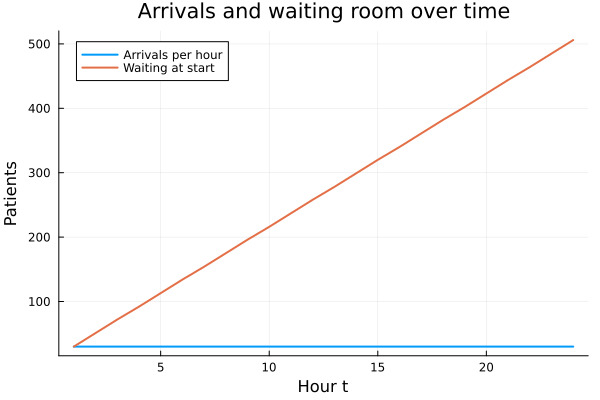

In [15]:
using Plots

# Arrivals per hour from the Dict N
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# Waiting room count at the start of each hour
waiting_per_t_vec = [value(sum(w[i,t,a] for i in I, a in 0:T)) for t in 1:T]

println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Line plot
plt = plot(1:T, arrivals_per_t,
    label = "Arrivals per hour",
    xlabel = "Hour t",
    ylabel = "Patients",
    title = "Arrivals and waiting room over time",
    legend = :topleft,
    lw = 2,
)
plot!(plt, 1:T, waiting_per_t_vec, label = "Waiting at start", lw = 2)


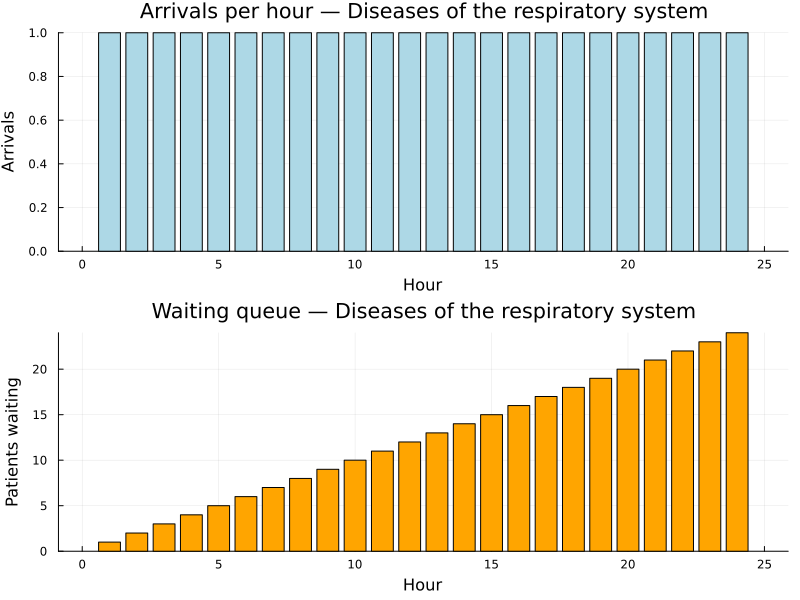

In [16]:
using Plots


function plot_disease_summary(disease_name::String)
    # Look up the disease index from the arrivals DataFrame
    rows = filter(:disease_name => ==(disease_name), arrivals_df)
    if nrow(rows) == 0
        println("Disease not found: ", disease_name)
        return
    end
    i = unique(rows.disease_index)[1]

    # Compute arrivals per hour for this disease
    arrivals_i = [N[(i,t)] for t in 1:T]

    # Compute queue (sum over all ages) from model results
    queue_i = [value(sum(w[i,t,a] for a in 0:T)) for t in 1:T]

    # Plot side by side "boxes" (bar charts)
    plt1 = bar(1:T, arrivals_i,
        xlabel = "Hour",
        ylabel = "Arrivals",
        title = "Arrivals per hour — $(disease_name)",
        legend = false,
        color = :lightblue,
    )

    plt2 = bar(1:T, queue_i,
        xlabel = "Hour",
        ylabel = "Patients waiting",
        title = "Waiting queue — $(disease_name)",
        legend = false,
        color = :orange,
    )

    # Combine vertically
    plot(plt1, plt2, layout = (2,1), size = (800,600))
end

plot_disease_summary("Diseases of the respiratory system")



We will walk through solving the easiest model:
\begin{align*}
    \min \quad 
    & \sum_{i=1}^n g_i w_i
    \\
    \text{s.t.} \quad 
    & \sum_{j=1}^n a_{ij} x_j \leq b_i,
    && \quad \forall \ i \in \{ 1, \dots, m \}
    \\
    & x_j \geq 0,
    && \quad \forall \ j \in \{ 1, \dots, n \}
\end{align*}